In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, top_k_accuracy_score, f1_score
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

print("Loading data...")
csv_path = "/content/drive/MyDrive/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(csv_path)
print(f"Initial Dataset Shape: {df.shape}")

Connecting to Google Drive...
Mounted at /content/drive
Loading data...
Initial Dataset Shape: (246945, 378)


In [ ]:
target_col = "diseases"
feature_cols = [c for c in df.columns if c != target_col]

# 1. Memory Optimization
X = df[feature_cols].astype(np.uint8)
y_raw = df[target_col]

# 2. Drop Zero-Variance Features
nunique = X.nunique()
useless_cols = nunique[nunique <= 1].index.tolist()
if useless_cols:
    X = X.drop(columns=useless_cols)

# 3. Drop Exact Duplicates
combined = X.copy()
combined['__target__'] = y_raw
dup_mask = combined.duplicated(keep='first').values
X = X[~dup_mask].reset_index(drop=True)
y_raw = y_raw[~dup_mask].reset_index(drop=True)

# 4. Drop Rare Classes (<2 samples)
class_counts = y_raw.value_counts()
rare_classes = class_counts[class_counts < 2].index
if len(rare_classes) > 0:
    mask = ~y_raw.isin(rare_classes)
    X = X[mask].reset_index(drop=True)
    y_raw = y_raw[mask].reset_index(drop=True)

# 5. Perfect Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
new_num_classes = len(le.classes_)

print(f"Cleaned Data -> Rows: {X.shape[0]}, Features: {X.shape[1]}, Valid Classes: {new_num_classes}")

Cleaned Data -> Rows: 189601, Features: 328, Valid Classes: 727


In [ ]:
# Notice we are passing y_encoded!
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data:  {X_test.shape[0]} rows")

Training Data: 151680 rows
Testing Data:  37921 rows


In [ ]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "multi:softprob",
    "num_class": new_num_classes,
    "eval_metric": ["mlogloss", "merror"],
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.05,
    "gamma": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "min_child_weight": 3,
    "seed": RANDOM_STATE,
}

print("Training Finetuned XGBoost on GPU...")
evals_result = {}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, "train") , (dtest, "val")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=100,
)
print(f"\nXGBoost Best iteration: {xgb_model.best_iteration}")

Training Finetuned XGBoost on GPU...
[0]	train-mlogloss:5.01464	train-merror:0.67697	val-mlogloss:5.02719	val-merror:0.68419
[100]	train-mlogloss:0.69996	train-merror:0.15284	val-mlogloss:0.80232	val-merror:0.20145
[142]	train-mlogloss:0.57386	train-merror:0.14060	val-mlogloss:0.69035	val-merror:0.20429

XGBoost Best iteration: 92


In [ ]:
from lightgbm import LGBMClassifier

print("Preparing collision-free feature names for LightGBM...")
safe_column_names = [f"feature_{i}" for i in range(X_train.shape[1])]

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
X_train_lgb.columns = safe_column_names
X_test_lgb.columns = safe_column_names

print("Training LightGBM Classifier...")
lgbm_model = LGBMClassifier(
    objective='multiclass',       # force full class space explicitly rather than auto-detect
    num_class=new_num_classes,    # matches XGBoost's num_class -- keeps behavior consistent
    n_estimators=300,
    max_depth=8,
    num_leaves=64,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    eval_metric='multi_logloss',
    callbacks=[
        __import__('lightgbm').early_stopping(stopping_rounds=25, verbose=False),
        __import__('lightgbm').log_evaluation(period=50),
    ],
)
print(f"\nLightGBM trained. Best iteration: {lgbm_model.best_iteration_}")
print(f"Classes seen during training: {len(lgbm_model.classes_)} / {new_num_classes}")


Preparing collision-free feature names for LightGBM...
Training LightGBM Classifier...

LightGBM trained. Best iteration: 1
Classes seen during training: 727 / 727


In [ ]:
print("Training Gradient Boosting (Optimized for Time)...")
gb_model = HistGradientBoostingClassifier(
    max_iter=30, max_depth=5, learning_rate=0.2, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=5,
    random_state=RANDOM_STATE, verbose=1
)
gb_model.fit(X_train, y_train)
print("Gradient Boosting successfully trained!")

Training Gradient Boosting (Optimized for Time)...
Binning 0.358 GB of training data: 3.136 s
Binning 0.040 GB of validation data: 0.122 s
Fitting gradient boosted rounds:
Fit 5089 trees in 1051.182 s, (75029 total leaves)
Time spent computing histograms: 977.449s
Time spent finding best splits:  4.720s
Time spent applying splits:      10.062s
Time spent predicting:           1.725s
Gradient Boosting successfully trained!


In [ ]:
print("Training Random Forest (memory-safe but stronger)...")
rf_model = RandomForestClassifier(
    n_estimators=120,      # was 30 -- too few trees for a 727-class problem, badly underfit
    max_depth=18,          # was 12 -- also too shallow to separate 727 classes
    min_samples_leaf=2,
    max_features='sqrt',
    max_samples=0.5,       # bootstrap only half the rows per tree -> keeps memory bounded
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)
rf_model.fit(X_train, y_train)
print(f"\nRandom Forest trained. Classes seen: {len(rf_model.classes_)} / {new_num_classes}")


Training Random Forest (memory-safe but stronger)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    6.6s



Random Forest trained. Classes seen: 727 / 727


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:   17.0s finished


In [ ]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=25,           # was 15 -- too shallow for 727 classes, was badly underfit
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
)
dt_model.fit(X_train, y_train)
print(f"\nDecision Tree trained. Depth: {dt_model.get_depth()}, Leaves: {dt_model.get_n_leaves()}")
print(f"Classes seen: {len(dt_model.classes_)} / {new_num_classes}")


Training Decision Tree...

Decision Tree trained. Depth: 25, Leaves: 340
Classes seen: 727 / 727


## THE FIX: remap every sklearn-style model's probabilities into the full class-ID space
`predict_proba()` for LightGBM / Random Forest / Decision Tree / HistGradientBoosting only returns columns for classes the model actually saw in `.fit()`, ordered by `model.classes_` -- **not** guaranteed to be `[0, 1, 2, ... N-1]`. `expand_proba()` below places each model's columns at their *true* class index before any `argmax` happens, so column index always equals real class ID. XGBoost's `Booster.predict()` doesn't need this -- it already outputs the full fixed-width vector in correct order by design.

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.8s
[Parallel(n_jobs=2)]: Done 120 out of 120 | elapsed:    9.2s finished



--- Final Model Leaderboard (Corrected) ---
                          Top-1   Top-3   Top-5  Weighted F1
XGBoost                  0.7992  0.9204  0.9483       0.7905
Voting Ensemble (All 5)  0.7729  0.9246  0.9609       0.7851
Gradient Boosting        0.7531  0.9001  0.9372       0.7502
Random Forest            0.6444  0.7562  0.7872       0.6488
LightGBM                 0.5293  0.8092  0.8727       0.5848
Decision Tree            0.1481  0.1806  0.2037       0.1822


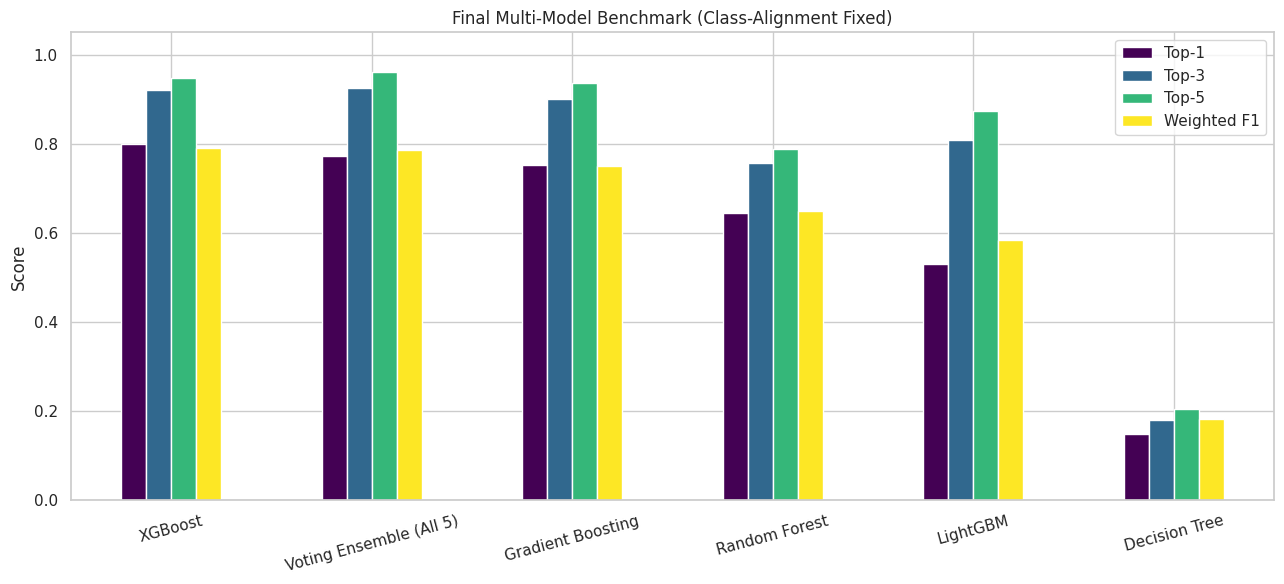

In [ ]:
def expand_proba(model, proba, num_classes):
    """Expand a sklearn-style model's predict_proba() output (which only
    has columns for classes seen during .fit()) into the FULL class-ID
    space, placing each column at its true class index. Classes the
    model never saw get 0 probability. THIS IS THE CRITICAL FIX --
    without it, argmax(proba) silently returns the wrong class whenever
    a model's classes_ isn't a clean [0..num_classes-1]."""
    full = np.zeros((proba.shape[0], num_classes))
    full[:, model.classes_] = proba
    return full

results = {}

def evaluate(name, y_proba):
    y_pred = np.argmax(y_proba, axis=1)
    top1 = accuracy_score(y_test, y_pred)
    try:
        top3 = top_k_accuracy_score(y_test, y_proba, k=3, labels=np.arange(new_num_classes))
        top5 = top_k_accuracy_score(y_test, y_proba, k=5, labels=np.arange(new_num_classes))
    except ValueError:
        top3, top5 = 0.0, 0.0
    f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'Top-1': top1, 'Top-3': top3, 'Top-5': top5, 'Weighted F1': f1w}

# --- Extract probabilities (XGBoost needs no fix; the other 4 do) ---
xgb_proba = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration + 1))
lgbm_proba = expand_proba(lgbm_model, lgbm_model.predict_proba(X_test_lgb), new_num_classes)
gb_proba   = expand_proba(gb_model,   gb_model.predict_proba(X_test),     new_num_classes)
rf_proba   = expand_proba(rf_model,   rf_model.predict_proba(X_test),     new_num_classes)
dt_proba   = expand_proba(dt_model,   dt_model.predict_proba(X_test),     new_num_classes)

evaluate('XGBoost', xgb_proba)
evaluate('LightGBM', lgbm_proba)
evaluate('Gradient Boosting', gb_proba)
evaluate('Random Forest', rf_proba)
evaluate('Decision Tree', dt_proba)

ensemble_proba = (xgb_proba + lgbm_proba + gb_proba + rf_proba + dt_proba) / 5.0
evaluate('Voting Ensemble (All 5)', ensemble_proba)

comparison_df = pd.DataFrame(results).T.sort_values('Top-1', ascending=False)
print("\n--- Final Model Leaderboard (Corrected) ---")
print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(13, 6), colormap='viridis')
plt.title('Final Multi-Model Benchmark (Class-Alignment Fixed)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


Composite weights (avg of Top-1/3/5):
  XGBoost: 0.8893
  Gradient Boosting: 0.8635
  LightGBM: 0.7370
  Random Forest: 0.7293
  Decision Tree: 0.1774

--- Updated Leaderboard (with Weighted Voting) ---
                             Top-1   Top-3   Top-5  Weighted F1
XGBoost                     0.7992  0.9204  0.9483       0.7905
Voting Ensemble (Weighted)  0.7804  0.9253  0.9613       0.7899
Voting Ensemble (All 5)     0.7729  0.9246  0.9609       0.7851
Gradient Boosting           0.7531  0.9001  0.9372       0.7502
Random Forest               0.6444  0.7562  0.7872       0.6488
LightGBM                    0.5293  0.8092  0.8727       0.5848
Decision Tree               0.1481  0.1806  0.2037       0.1822


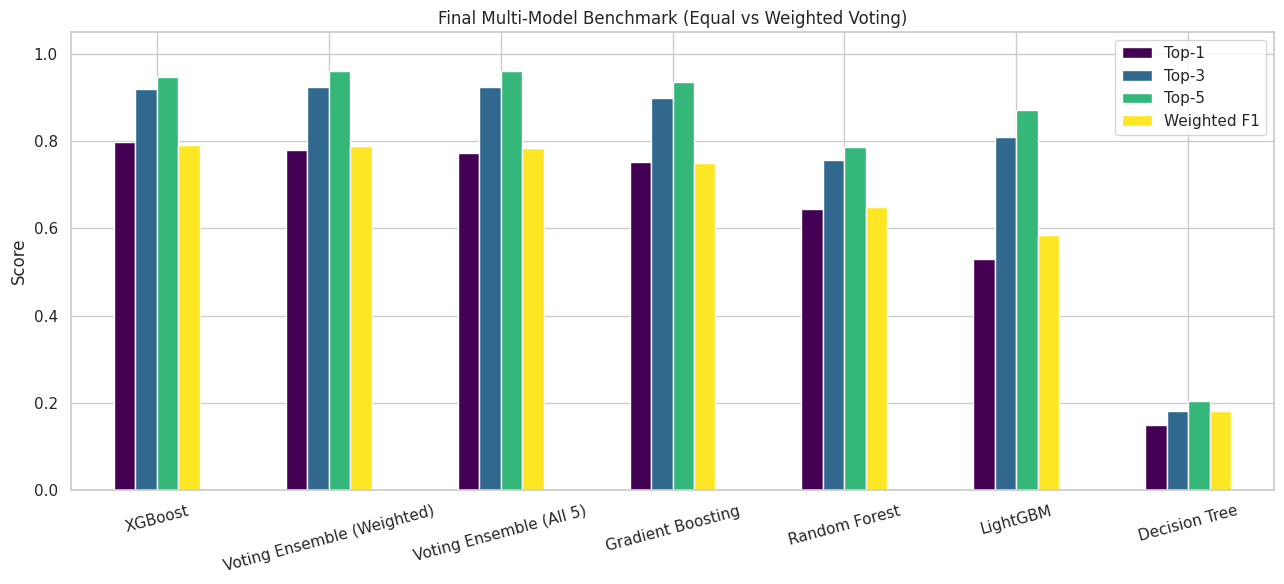

In [ ]:
# Weighted Voting: weight each model by a composite of Top-1, Top-3, AND Top-5
# accuracy (not just Top-1 alone), so a model that's weak on the top pick but
# strong at getting the right answer into its top few candidates still counts
model_names = ['XGBoost', 'Gradient Boosting', 'LightGBM', 'Random Forest', 'Decision Tree']

weights = {
    name: (results[name]['Top-1'] + results[name]['Top-3'] + results[name]['Top-5']) / 3
    for name in model_names
}

print("Composite weights (avg of Top-1/3/5):")
for name, w in weights.items():
    print(f"  {name}: {w:.4f}")

total = sum(weights.values())

weighted_proba = (
    weights['XGBoost'] * xgb_proba +
    weights['Gradient Boosting'] * gb_proba +
    weights['LightGBM'] * lgbm_proba +
    weights['Random Forest'] * rf_proba +
    weights['Decision Tree'] * dt_proba
) / total

evaluate('Voting Ensemble (Weighted)', weighted_proba)

comparison_df = pd.DataFrame(results).T.sort_values('Top-1', ascending=False)
print("\n--- Updated Leaderboard (with Weighted Voting) ---")
print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(13, 6), colormap='viridis')
plt.title('Final Multi-Model Benchmark (Equal vs Weighted Voting)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
import os
import json
import joblib

# 1. Define the target directory in Google Drive
base_dir = "/content/drive/MyDrive/MedAssist_Models"

# 2. Check if the folder exists, if not, create it
if not os.path.exists(base_dir):
    os.makedirs(base_dir)
    print(f"Created new directory at: {base_dir}")
else:
    print(f"Directory already exists at: {base_dir}")

print("-" * 40)
print("Saving models and encoders...")

# 3. Save XGBoost (Native JSON support)
xgb_path = os.path.join(base_dir, "xgboost_model.json")
xgb_model.save_model(xgb_path)
print("✅ XGBoost saved as JSON.")

# 4. Save LightGBM (Native TXT support)
lgbm_path = os.path.join(base_dir, "lightgbm_model.txt")
lgbm_model.booster_.save_model(lgbm_path)
print("✅ LightGBM saved as TXT.")

# 5. Save Scikit-Learn Models (Requires joblib)
joblib.dump(gb_model, os.path.join(base_dir, "gradient_boosting_model.joblib"))
print("✅ Gradient Boosting saved as Joblib.")

joblib.dump(rf_model, os.path.join(base_dir, "random_forest_model.joblib"))
print("✅ Random Forest saved as Joblib.")

joblib.dump(dt_model, os.path.join(base_dir, "decision_tree_model.joblib"))
print("✅ Decision Tree saved as Joblib.")

# 6. Save the Label Encoder (for Python loading)
joblib.dump(le, os.path.join(base_dir, "label_encoder.joblib"))
print("✅ Label Encoder saved as Joblib.")

# 7. Save Disease Classes as JSON (Perfect for your FastAPI backend)
class_mapping = {int(index): str(disease) for index, disease in enumerate(le.classes_)}
json_mapping_path = os.path.join(base_dir, "disease_classes.json")
with open(json_mapping_path, "w") as f:
    json.dump(class_mapping, f, indent=4)
print("✅ Disease class mapping saved as JSON.")

# 8. Save the Ensemble Weights
weights_path = os.path.join(base_dir, "ensemble_weights.json")
with open(weights_path, "w") as f:
    json.dump(weights, f, indent=4)
print("✅ Ensemble weights saved as JSON.")

print("-" * 40)
print("🎉 All assets successfully saved to Google Drive!")

Created new directory at: /content/drive/MyDrive/MedAssist_Models
----------------------------------------
Saving models and encoders...
✅ XGBoost saved as JSON.
✅ LightGBM saved as TXT.
✅ Gradient Boosting saved as Joblib.
✅ Random Forest saved as Joblib.
✅ Decision Tree saved as Joblib.
✅ Label Encoder saved as Joblib.
✅ Disease class mapping saved as JSON.
✅ Ensemble weights saved as JSON.
----------------------------------------
🎉 All assets successfully saved to Google Drive!
